# Предобработка текстовых данных

In [1]:
from __future__ import annotations

import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path

%matplotlib inline

### Определение путей к данным

In [35]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
RAW_PATH = DATA_DIR / "raw_posts_labeled.csv"
PROCESSED_PATH = DATA_DIR / "processed_posts.csv"


### Функции очистки текста

In [3]:
URL_RE = re.compile(r"http\S+|www\.\S+|t\.me/\S+")
MENTION_RE = re.compile(r"@\w+")
HASHTAG_RE = re.compile(r"#\w+")
NON_LETTERS_RE = re.compile(r"[^a-zA-Zа-яА-ЯёЁ\s]")


def clean_text(text: str) -> str:
    """
    Простая очистка текста:
      - убираем ссылки, @упоминания, #хэштеги
      - приводим к нижнему регистру
      - выкидываем цифры, лишние символы и пунктуацию
      - схлопываем лишние пробелы
    """
    if not isinstance(text, str):
        return ""

    # нижний регистр
    t = text.lower()

    # ссылки, упоминания, хэштеги
    t = URL_RE.sub(" ", t)
    t = MENTION_RE.sub(" ", t)
    t = HASHTAG_RE.sub(" ", t)

    # убираем всё, кроме букв и пробелов
    t = NON_LETTERS_RE.sub(" ", t)

    # схлопываем пробелы
    t = re.sub(r"\s+", " ", t).strip()

    return t

### Загрузка и предобработка текстовых данных

In [4]:
def preprocess_data(min_len: int = 10):
    """
    Загружаем сырой датасет → чистим тексты → фильтруем совсем короткие →
    сохраняем processed_posts.csv
    """
    if not RAW_PATH.exists():
        raise FileNotFoundError(f"Не найден файл {RAW_PATH}")

    print(f"[*] Загружаем сырой датасет: {RAW_PATH}")
    df = pd.read_csv(RAW_PATH)

    # Проверим, что нужные колонки есть
    if "text" not in df.columns:
        raise ValueError("В raw_posts_labeled.csv нет колонки 'text'")

    df = df.dropna(subset=["text"])
    df = df[df["text"].astype(str).str.strip() != ""]

    print(f"[*] Строк после удаления пустых текстов: {len(df)}")

    print("[*] Очищаем тексты...")
    df["text_clean"] = df["text"].astype(str).apply(clean_text)

    # Фильтруем слишком короткие очищенные тексты
    before_len = len(df)
    df = df[df["text_clean"].str.len() >= min_len]
    print(f"[*] Убрали слишком короткие тексты: {before_len} → {len(df)}")

    df = df.drop_duplicates(subset=["text_clean", "topic"], keep="first")

    # Сохраняем только нужные колонки
    keep_cols = []
    for col in ["id", "date", "channel", "topic", "text", "text_clean"]:
        if col in df.columns:
            keep_cols.append(col)

    df = df[keep_cols]

    DATA_DIR.mkdir(exist_ok=True)
    df.to_csv(PROCESSED_PATH, index=False)

    print(f"[+] Обработанный датасет сохранён: {PROCESSED_PATH} (строк: {len(df)})")
    
    return df 

if RAW_PATH.exists():
    processed_df = preprocess_data(min_len=15) 
    print(f"\nРазмер датасета: {len(processed_df)} строк")
    print(f"Колонки: {list(processed_df.columns)}")

[*] Загружаем сырой датасет: d:\studying\projectYear\classificationMLlinear\data\raw_posts_labeled.csv
[*] Строк после удаления пустых текстов: 262
[*] Очищаем тексты...
[*] Убрали слишком короткие тексты: 262 → 258
[+] Обработанный датасет сохранён: d:\studying\projectYear\classificationMLlinear\data\processed_posts.csv (строк: 257)

Размер датасета: 257 строк
Колонки: ['date', 'topic', 'text', 'text_clean']


## Dataset split

In [5]:
from __future__ import annotations
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split

In [6]:
ML_DIR = Path.cwd() 
PROJECT_ROOT = ML_DIR.parent  # Корень проекта
DATA_DIR = PROJECT_ROOT / "data"
SPLIT_DIR = DATA_DIR / "splits"
TRAIN_PATH = SPLIT_DIR / "train.csv"
VAL_PATH = SPLIT_DIR / "val.csv"
TEST_PATH = SPLIT_DIR / "test.csv"

### Split function

In [7]:
def main(
    test_size: float = 0.15,
    val_size: float = 0.15,
    random_state: int = 42,
):
    """
    Делим processed_posts.csv на train / val / test и сохраняем в data/splits.
    """

    if not PROCESSED_PATH.exists():
        raise FileNotFoundError(f"Не найден файл {PROCESSED_PATH}")

    print(f"[*] Загружаем обработанный датасет: {PROCESSED_PATH}")
    df = pd.read_csv(PROCESSED_PATH)

    if "topic" not in df.columns:
        raise ValueError("В processed_posts.csv нет колонки 'topic'")

    df = df.dropna(subset=["topic"])
    df["topic"] = df["topic"].astype(str)

    print(f"[*] Всего строк для разбиения: {len(df)}")

    # === 1. Выделяем test ===
    df_train_val, df_test = train_test_split(
        df,
        test_size=test_size,
        stratify=df["topic"],
        random_state=random_state,
    )

    # === 2. Делим train_val на train и val ===
    val_rel_size = val_size / (1.0 - test_size)

    df_train, df_val = train_test_split(
        df_train_val,
        test_size=val_rel_size,
        stratify=df_train_val["topic"],
        random_state=random_state,
    )

    print(f"[*] Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")

    SPLIT_DIR.mkdir(exist_ok=True)

    df_train.to_csv(TRAIN_PATH, index=False)
    df_val.to_csv(VAL_PATH, index=False)
    df_test.to_csv(TEST_PATH, index=False)

    print(f"[+] Train сохранён в: {TRAIN_PATH}")
    print(f"[+] Val   сохранён в: {VAL_PATH}")
    print(f"[+] Test  сохранён в: {TEST_PATH}")


print("Шаг 2: Разделение данных на train/val/test")

if PROCESSED_PATH.exists():
    main()
else:
    print(f"Файл не найден: {PROCESSED_PATH}")
    print("Сначала выполните предобработку данных.")

Шаг 2: Разделение данных на train/val/test
[*] Загружаем обработанный датасет: d:\studying\projectYear\classificationMLlinear\data\processed_posts.csv
[*] Всего строк для разбиения: 257
[*] Train: 179, Val: 39, Test: 39
[+] Train сохранён в: d:\studying\projectYear\classificationMLlinear\data\splits\train.csv
[+] Val   сохранён в: d:\studying\projectYear\classificationMLlinear\data\splits\val.csv
[+] Test  сохранён в: d:\studying\projectYear\classificationMLlinear\data\splits\test.csv


# Baseline models

### Загрузка split data

In [8]:
from pathlib import Path
import pandas as pd
import numpy as np

In [9]:
ML_DIR = Path.cwd() 
PROJECT_ROOT = ML_DIR.parent  
DATA_DIR = PROJECT_ROOT / "data"
SPLIT_DIR = DATA_DIR / "splits"

train_path = SPLIT_DIR / "train.csv"
val_path = SPLIT_DIR / "val.csv"
test_path = SPLIT_DIR / "test.csv"

print(f"Train файл: {train_path} - {train_path.exists()}")
print(f"Val файл: {val_path} - {val_path.exists()}")
print(f"Test файл: {test_path} - {test_path.exists()}")

if all([train_path.exists(), val_path.exists(), test_path.exists()]):
    # Загружаем данные
    train_df = pd.read_csv(train_path)
    val_df = pd.read_csv(val_path)
    test_df = pd.read_csv(test_path)
    print(f"  Train: {len(train_df)} строк")
    print(f"  Val:   {len(val_df)} строк")
    print(f"  Test:  {len(test_df)} строк")

Train файл: d:\studying\projectYear\classificationMLlinear\data\splits\train.csv - True
Val файл: d:\studying\projectYear\classificationMLlinear\data\splits\val.csv - True
Test файл: d:\studying\projectYear\classificationMLlinear\data\splits\test.csv - True
  Train: 179 строк
  Val:   39 строк
  Test:  39 строк


In [10]:
files_exist = all([train_path.exists(), val_path.exists(), test_path.exists()])

if files_exist:
    # Загружаем данные
    train_df = pd.read_csv(train_path)
    val_df = pd.read_csv(val_path)
    test_df = pd.read_csv(test_path)
    
    print(f"\nДанные успешно загружены:")
    print(f"  Train: {len(train_df)} строк")
    print(f"  Val:   {len(val_df)} строк")
    print(f"  Test:  {len(test_df)} строк")
    
    text_column = "text_clean" if "text_clean" in train_df.columns else "text"
    
    X_train = train_df[text_column].astype(str)
    y_train = train_df["topic"].astype(str)
    
    X_val = val_df[text_column].astype(str)
    y_val = val_df["topic"].astype(str)
    
    X_test = test_df[text_column].astype(str)
    y_test = test_df["topic"].astype(str)
    
    # Сохраняем в глобальные переменные для использования в следующих ячейках
    print(f"\nДанные подготовлены и сохранены в переменных:")
    print(f"  X_train, y_train - для обучения")
    print(f"  X_val, y_val     - для валидации и настройки")
    print(f"  X_test, y_test   - для финального тестирования")
    
else:
    print(f"\n все файлы найдены в {SPLIT_DIR}")
    print("Сначала выполните разделение данных (dataset_split.py)")

    train_df = val_df = test_df = None
    X_train = X_val = X_test = y_train = y_val = y_test = None


Данные успешно загружены:
  Train: 179 строк
  Val:   39 строк
  Test:  39 строк

Данные подготовлены и сохранены в переменных:
  X_train, y_train - для обучения
  X_val, y_val     - для валидации и настройки
  X_test, y_test   - для финального тестирования


Векторизация текста

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# Проверяем, что данные загружены
if X_train is not None:
    text_col = "text_clean" if "text_clean" in train_df.columns else "text"
    print(f"[*] Используем колонку: '{text_col}'")
    
    tfidf = TfidfVectorizer(
        ngram_range=(1, 2),    # 1-2 граммы
        min_df=5,              # слово должно встретиться минимум в 5 документах
        max_features=20000,    # максимум 20к признаков
    )
    
    print(f"[*] TF-IDF vectorizer (1-2 граммы) по колонке '{text_col}'")
    print(f"    Параметры: ngram_range={tfidf.ngram_range}, min_df={tfidf.min_df}, max_features={tfidf.max_features}")
    
    # Векторизация train и val
    X_train_vec = tfidf.fit_transform(X_train)
    X_val_vec = tfidf.transform(X_val)
    X_test_vec = tfidf.transform(X_test)
    
    print(f"[*] Размерность признаков: {X_train_vec.shape[1]}")
    print(f"[*] Размерности матриц:")
    print(f"    Train: {X_train_vec.shape}")
    print(f"    Val:   {X_val_vec.shape}")
    print(f"    Test:  {X_test_vec.shape}")
    
    print("\n[*] Кодируем метки классов...")
    le = LabelEncoder()
    y_train_encoded = le.fit_transform(y_train)
    y_val_encoded = le.transform(y_val)
    y_test_encoded = le.transform(y_test)
    
    print(f"[*] Найденные классы ({len(le.classes_)}): {list(le.classes_)}")
    print(f"[*] Распределение классов в train (закодировано):")
    unique, counts = np.unique(y_train_encoded, return_counts=True)
    for cls_idx, count in zip(unique, counts):
        cls_name = le.inverse_transform([cls_idx])[0]
        print(f"    {cls_name} (idx={cls_idx}): {count} примеров")
    
    print(f"\nВекторизация и кодирование завершены")
    print(f"  Сохранены переменные:")
    print(f"    tfidf - TF-IDF векторизатор")
    print(f"    le - LabelEncoder для меток классов")
    print(f"    X_train_vec, y_train_encoded - для обучения")
    print(f"    X_val_vec, y_val_encoded - для валидации")
    print(f"    X_test_vec, y_test_encoded - для тестирования")
    
else:
    print("Данные не загружены. Сначала выполните ячейку загрузки данных.")

[*] Используем колонку: 'text_clean'
[*] TF-IDF vectorizer (1-2 граммы) по колонке 'text_clean'
    Параметры: ngram_range=(1, 2), min_df=5, max_features=20000
[*] Размерность признаков: 242
[*] Размерности матриц:
    Train: (179, 242)
    Val:   (39, 242)
    Test:  (39, 242)

[*] Кодируем метки классов...
[*] Найденные классы (11): ['0', '1', '10', '2', '3', '4', '5', '6', '7', '8', '9']
[*] Распределение классов в train (закодировано):
    0 (idx=0): 22 примеров
    1 (idx=1): 17 примеров
    10 (idx=2): 30 примеров
    2 (idx=3): 8 примеров
    3 (idx=4): 41 примеров
    4 (idx=5): 15 примеров
    5 (idx=6): 10 примеров
    6 (idx=7): 16 примеров
    7 (idx=8): 12 примеров
    8 (idx=9): 5 примеров
    9 (idx=10): 3 примеров

Векторизация и кодирование завершены
  Сохранены переменные:
    tfidf - TF-IDF векторизатор
    le - LabelEncoder для меток классов
    X_train_vec, y_train_encoded - для обучения
    X_val_vec, y_val_encoded - для валидации
    X_test_vec, y_test_encoded - 

In [12]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression, SGDClassifier, RidgeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC, NuSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

from sklearn.metrics import (
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    classification_report
)

In [13]:
import warnings
warnings.filterwarnings("ignore")

In [14]:
RANDOM_STATE = 42

In [15]:
X_train = X_train_vec
X_test = X_val_vec  
y_train = y_train_encoded
y_test = y_val_encoded

In [16]:
def print_metrics(y_true, y_pred):
    metrics = calc_metrics(y_true, y_pred)
    for key, value in metrics.items():
        print(f'{value:10.4f} -- {key}')

def calc_metrics(y_true, y_pred):
    return {
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_micro": f1_score(y_true, y_pred, average="micro"),
        "precision_micro": precision_score(y_true, y_pred, average="micro", zero_division=0),
        "recall_micro": recall_score(y_true, y_pred, average="micro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
    }

In [17]:
def run_model(model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print_metrics(y_test, y_pred)

In [18]:
run_model(NuSVC(nu=0.1))

    0.0865 -- f1_macro
    0.2564 -- accuracy
    0.0835 -- precision_macro
    0.1097 -- recall_macro
    0.2564 -- f1_micro
    0.2564 -- precision_micro
    0.2564 -- recall_micro
    0.1940 -- f1_weighted
    0.1811 -- precision_weighted
    0.2564 -- recall_weighted


In [19]:
models = [
    ("LogReg-ovr", LogisticRegression(multi_class='ovr'), {
        'C': [0.01, 0.1, 0.5, 1, 10, 100]
    }),
    ("LogReg-multinomial", LogisticRegression(multi_class='multinomial'), {
        'C': [0.01, 0.1, 0.5, 1, 10, 100]
    }),
    ("SGDClassifier", SGDClassifier(), {
        'alpha': [0.01, 0.1, 0.5, 1, 10],
        'l1_ratio': [0.01, 0.1, 0.15, 0.5, 1]
    }),
    ("LinearSVC", LinearSVC(), {
        'C': [0.01, 0.1, 0.5, 1, 10, 100]
    }),
    ("RidgeClassifier", RidgeClassifier(), {
        'alpha': [0.01, 0.1, 0.5, 1, 10]
    }),
    ("MultinomialNB", MultinomialNB(), {
        'alpha': [0.01, 0.1, 0.5, 1, 10]
    }),
    ("KNN_k11", KNeighborsClassifier(n_neighbors=11), {
        'p': [0.5, 1, 1.5, 2, 5]
    }),
    ("NuSVC_nu0.1", NuSVC(nu=0.1), {
        'nu': [0.01, 0.05, 0.1, 0.2],
        'degree': [1, 2, 3],
        'coef0': [0, 0.01, .1, .5, 1, 10],
        'kernel': ['linear', 'poly', 'rbf', 'sigmoid']
    })
]

In [20]:
def print_metrics_result(metric_names, result):

    return pd.DataFrame(result).T

    # width = 15
    # print(f'model name          ', end='|')
    # for metric_name in metric_names:
    #     print(f' {metric_name:{width}}', end='|')
    # print()

    # for name, metrics in result.items():
    #     print(f'{name:20}', end='|')
    #     for metric_name in metric_names:
    #         print(f' {metrics[metric_name]:{width}.4f}', end='|')
    #     print()


In [21]:
metric_names = [
    "f1_macro", "f1_micro", "f1_weighted",
    "accuracy", 
    "precision_macro", "precision_micro", "precision_weighted",
    "recall_macro", "recall_micro", "recall_weighted"
]

In [22]:
# scoring = 'accuracy'
# scoring = 'f1_macro'
# scoring = 'precision'
scoring = 'recall_macro'

gs_list = []

for name, model, params in models:
    print(name)
    gs = GridSearchCV(model, params, cv=5, scoring=scoring)
    gs.fit(X_train, y_train)
    gs_list.append(gs)
    print(gs.best_params_)
    print()

LogReg-ovr
{'C': 100}

LogReg-multinomial
{'C': 100}

SGDClassifier
{'alpha': 0.01, 'l1_ratio': 0.01}

LinearSVC
{'C': 1}

RidgeClassifier
{'alpha': 0.5}

MultinomialNB
{'alpha': 0.1}

KNN_k11
{'p': 2}

NuSVC_nu0.1
{'coef0': 0, 'degree': 1, 'kernel': 'linear', 'nu': 0.1}



In [23]:
result_gs = {}
for model_tuple, gs in zip(models, gs_list):
    # model.fit(X_train, y_train)
    name, _, _ = model_tuple
    model = gs.best_estimator_
    y_pred = model.predict(X_test)
    result_gs[name] = calc_metrics(y_test, y_pred)

In [24]:
result = {}
for name, model, _ in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    result[name] = calc_metrics(y_test, y_pred)

In [25]:
print('Модели, подобранные GridSearchCV')
df_models_gs = print_metrics_result(metric_names, result_gs)
df_models_gs

Модели, подобранные GridSearchCV


,f1_macro,accuracy,precision_macro,recall_macro,f1_micro,precision_micro,recall_micro,f1_weighted,precision_weighted,recall_weighted
LogReg-ovr,0.212510,0.435897,0.197110,0.247258,0.435897,0.435897,0.435897,0.366473,0.333811,0.435897
LogReg-multinomial,0.212121,0.435897,0.196753,0.247258,0.435897,0.435897,0.435897,0.374033,0.343162,0.435897
SGDClassifier,0.357526,0.487179,0.433410,0.335281,0.487179,0.487179,0.487179,0.453597,0.481146,0.487179
LinearSVC,0.214747,0.435897,0.206818,0.247258,0.435897,0.435897,0.435897,0.368490,0.341667,0.435897
RidgeClassifier,0.267821,0.435897,0.283333,0.279726,0.435897,0.435897,0.435897,0.385511,0.368803,0.435897
MultinomialNB,0.176584,0.384615,0.177056,0.211544,0.384615,0.384615,0.384615,0.315385,0.319536,0.384615
KNN_k11,0.210741,0.358974,0.234091,0.239466,0.358974,0.358974,0.358974,0.351833,0.414744,0.358974
NuSVC_nu0.1,0.311846,0.435897,0.315618,0.333261,0.435897,0.435897,0.435897,0.411292,0.426824,0.435897


In [26]:
df_models_gs.sort_values('f1_macro', ascending=False)

,f1_macro,accuracy,precision_macro,recall_macro,f1_micro,precision_micro,recall_micro,f1_weighted,precision_weighted,recall_weighted
SGDClassifier,0.357526,0.487179,0.433410,0.335281,0.487179,0.487179,0.487179,0.453597,0.481146,0.487179
NuSVC_nu0.1,0.311846,0.435897,0.315618,0.333261,0.435897,0.435897,0.435897,0.411292,0.426824,0.435897
RidgeClassifier,0.267821,0.435897,0.283333,0.279726,0.435897,0.435897,0.435897,0.385511,0.368803,0.435897
LinearSVC,0.214747,0.435897,0.206818,0.247258,0.435897,0.435897,0.435897,0.368490,0.341667,0.435897
LogReg-ovr,0.212510,0.435897,0.197110,0.247258,0.435897,0.435897,0.435897,0.366473,0.333811,0.435897
LogReg-multinomial,0.212121,0.435897,0.196753,0.247258,0.435897,0.435897,0.435897,0.374033,0.343162,0.435897
KNN_k11,0.210741,0.358974,0.234091,0.239466,0.358974,0.358974,0.358974,0.351833,0.414744,0.358974
MultinomialNB,0.176584,0.384615,0.177056,0.211544,0.384615,0.384615,0.384615,0.315385,0.319536,0.384615


In [27]:
print('Модели без подбора')
print_metrics_result(metric_names, result)

Модели без подбора


,f1_macro,accuracy,precision_macro,recall_macro,f1_micro,precision_micro,recall_micro,f1_weighted,precision_weighted,recall_weighted
LogReg-ovr,0.082867,0.307692,0.071848,0.129870,0.307692,0.307692,0.307692,0.186686,0.156741,0.307692
LogReg-multinomial,0.095010,0.333333,0.080161,0.142857,0.333333,0.333333,0.333333,0.211876,0.174182,0.333333
SGDClassifier,0.254593,0.384615,0.270779,0.264719,0.384615,0.384615,0.384615,0.367876,0.392491,0.384615
LinearSVC,0.214747,0.435897,0.206818,0.247258,0.435897,0.435897,0.435897,0.368490,0.341667,0.435897
RidgeClassifier,0.199523,0.410256,0.184123,0.234271,0.410256,0.410256,0.410256,0.340832,0.308170,0.410256
MultinomialNB,0.071113,0.282051,0.069519,0.116883,0.282051,0.282051,0.282051,0.161869,0.150830,0.282051
KNN_k11,0.210741,0.358974,0.234091,0.239466,0.358974,0.358974,0.358974,0.351833,0.414744,0.358974
NuSVC_nu0.1,0.086510,0.256410,0.083471,0.109668,0.256410,0.256410,0.256410,0.193962,0.181119,0.256410


# Визуализация результатов

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

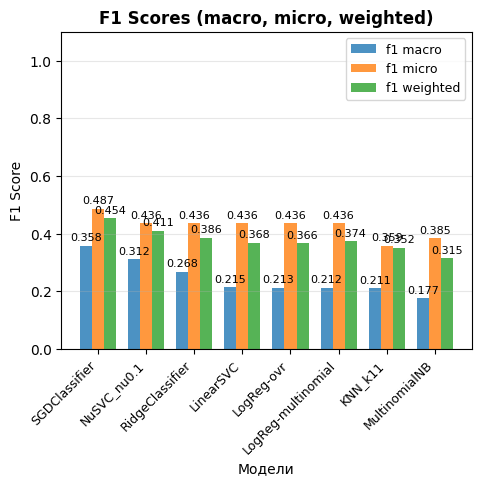

In [29]:
if 'df_models_gs' not in locals() or df_models_gs.empty:
    print("Нет результатов GridSearchCV. Сначала выполните предыдущие ячейки.")
else:
    fig = plt.figure(figsize=(18, 14))
    df_sorted = df_models_gs.sort_values('f1_macro', ascending=False)
    models_names = df_sorted.index
    n_models = len(models_names)
    colors = plt.cm.Set3(np.linspace(0, 1, n_models))
    
    # 1. F1 Scores (macro, micro, weighted)
    ax1 = plt.subplot(3, 3, 1)
    f1_metrics = ['f1_macro', 'f1_micro', 'f1_weighted']
    x = np.arange(n_models)
    width = 0.25
    
    for i, metric in enumerate(f1_metrics):
        offset = width * (i - 1)
        bars = ax1.bar(x + offset, df_sorted[metric], width=width, 
                      label=metric.replace('_', ' '), alpha=0.8)
        
        if n_models <= 8:
            for bar in bars:
                height = bar.get_height()
                if height > 0.01:  # Не показывать очень маленькие значения
                    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                            f'{height:.3f}', ha='center', va='bottom', fontsize=8)
    
    ax1.set_xlabel('Модели', fontsize=10)
    ax1.set_ylabel('F1 Score', fontsize=10)
    ax1.set_title('F1 Scores (macro, micro, weighted)', fontsize=12, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(models_names, rotation=45, ha='right', fontsize=9)
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.set_ylim([0, 1.1])

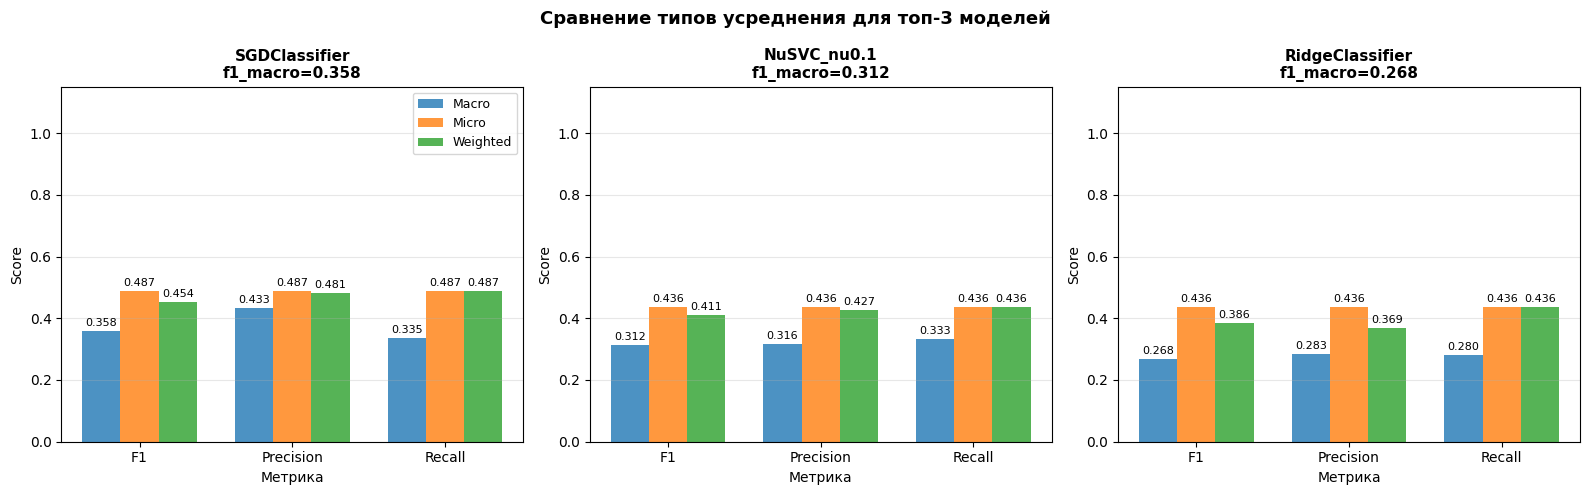

In [30]:
if 'df_models_gs' not in locals() or df_models_gs.empty:
    print("Нет результатов GridSearchCV. Сначала выполните предыдущие ячейки.")
else:
    top3_models = df_sorted.head(3)
    top3_names = top3_models.index
    
    fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5))
    
    for idx, (model_name, ax) in enumerate(zip(top3_names, axes2)):
        model_metrics = top3_models.loc[model_name]
        
        metric_groups = ['F1', 'Precision', 'Recall']
        avg_types = ['Macro', 'Micro', 'Weighted']
        
        data = np.array([
            [model_metrics['f1_macro'], model_metrics['f1_micro'], model_metrics['f1_weighted']],
            [model_metrics['precision_macro'], model_metrics['precision_micro'], model_metrics['precision_weighted']],
            [model_metrics['recall_macro'], model_metrics['recall_micro'], model_metrics['recall_weighted']]
        ])
        
        x = np.arange(len(metric_groups))
        width = 0.25
        
        for i, avg_type in enumerate(avg_types):
            bars = ax.bar(x + i*width - width, data[:, i], width=width, 
                         label=avg_type, alpha=0.8)
            
            for bar, value in zip(bars, data[:, i]):
                height = bar.get_height()
                if value > 0.1:  # Не показывать очень маленькие значения
                    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                           f'{value:.3f}', ha='center', va='bottom', fontsize=8)
        
        ax.set_xlabel('Метрика', fontsize=10)
        ax.set_ylabel('Score', fontsize=10)
        ax.set_title(f'{model_name}\nf1_macro={model_metrics["f1_macro"]:.3f}', 
                    fontsize=11, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(metric_groups)
        ax.set_ylim([0, 1.15])
        ax.grid(True, alpha=0.3, axis='y')
        
        if idx == 0:
            ax.legend(fontsize=9)
    
    plt.suptitle('Сравнение типов усреднения для топ-3 моделей', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    

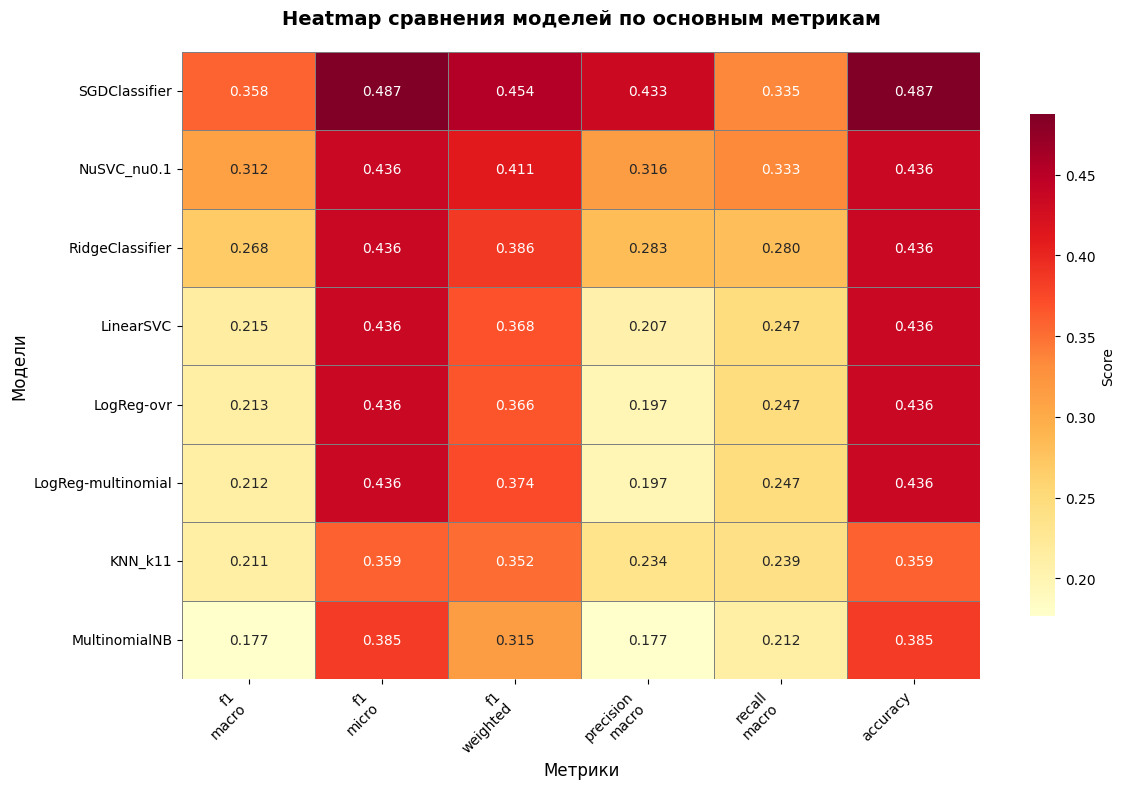

In [31]:
if 'df_models_gs' not in locals() or df_models_gs.empty:
    print("Нет результатов GridSearchCV. Сначала выполните предыдущие ячейки.")
else:
    fig3, ax3 = plt.subplots(figsize=(12, 8))
    heatmap_metrics = ['f1_macro', 'f1_micro', 'f1_weighted',
                      'precision_macro', 'recall_macro', 'accuracy']
    
    heatmap_data = df_sorted[heatmap_metrics]
    
    # Создаём heatmap
    sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd', 
                cbar_kws={'label': 'Score', 'shrink': 0.8},
                linewidths=0.5, linecolor='gray', ax=ax3)
    
    ax3.set_title('Heatmap сравнения моделей по основным метрикам', 
                 fontsize=14, fontweight='bold', pad=20)
    ax3.set_xlabel('Метрики', fontsize=12)
    ax3.set_ylabel('Модели', fontsize=12)
    
    ax3.set_xticklabels([m.replace('_', '\n') for m in heatmap_metrics], 
                        rotation=45, ha='right', fontsize=10)
    ax3.set_yticklabels(heatmap_data.index, rotation=0, fontsize=10)
    
    plt.tight_layout()
    plt.show()

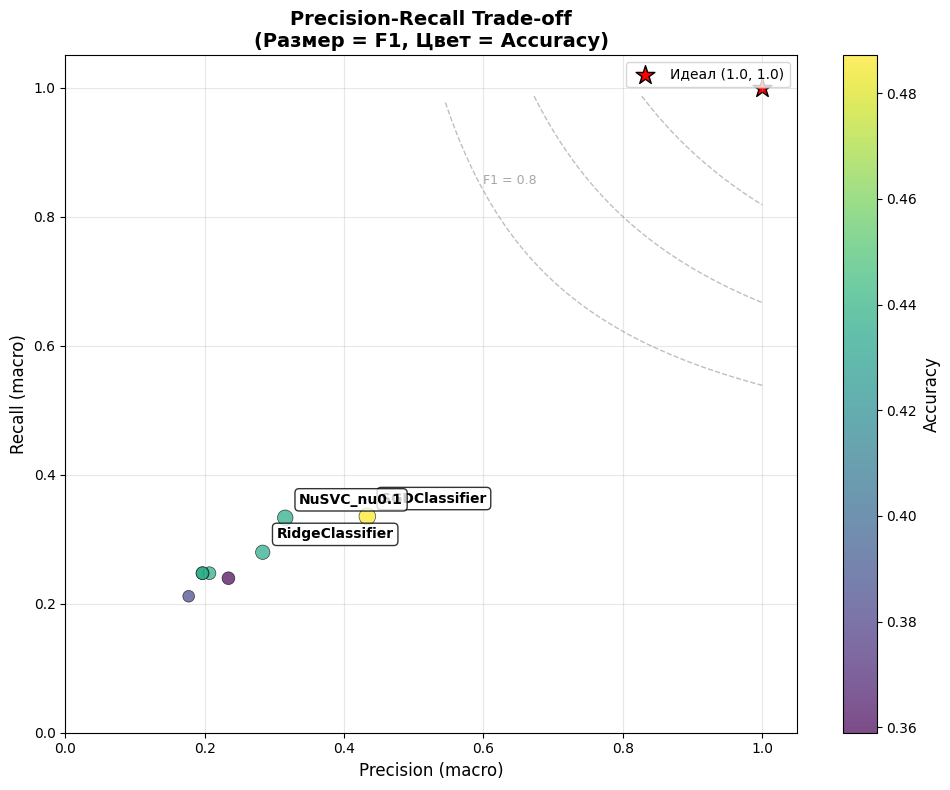

In [32]:
if 'df_models_gs' not in locals() or df_models_gs.empty:
    print("Нет результатов GridSearchCV. Сначала выполните предыдущие ячейки.")
else:
    fig4, ax4 = plt.subplots(figsize=(10, 8))
    
    # Scatter plot
    scatter = ax4.scatter(df_sorted['precision_macro'], df_sorted['recall_macro'],
                         s=df_sorted['f1_macro'] * 400,  # Размер по F1 score
                         c=df_sorted['accuracy'],        # Цвет по accuracy
                         cmap='viridis', alpha=0.7, edgecolors='black', linewidth=0.5)
    
    # Подписываем важные модели (топ-3 по F1)
    for model_name in top3_names:
        precision = df_sorted.loc[model_name, 'precision_macro']
        recall = df_sorted.loc[model_name, 'recall_macro']
        ax4.annotate(model_name, (precision, recall), 
                    xytext=(10, 10), textcoords='offset points',
                    fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
    
    # Идеальная точка
    ax4.scatter([1.0], [1.0], color='red', s=200, marker='*', 
               label='Идеал (1.0, 1.0)', edgecolors='black', linewidth=1)
    
    ax4.set_xlabel('Precision (macro)', fontsize=12)
    ax4.set_ylabel('Recall (macro)', fontsize=12)
    ax4.set_title('Precision-Recall Trade-off\n(Размер = F1, Цвет = Accuracy)', 
                 fontsize=14, fontweight='bold')
    ax4.grid(True, alpha=0.3)
    ax4.set_xlim([0, 1.05])
    ax4.set_ylim([0, 1.05])
    
    for f1 in [0.7, 0.8, 0.9]:
        x = np.linspace(0.1, 1, 100)
        y = f1 * x / (2 * x - f1)
        mask = (y >= 0) & (y <= 1)
        ax4.plot(x[mask], y[mask], '--', color='gray', alpha=0.5, linewidth=1)
        if f1 == 0.8:
            ax4.text(0.6, 0.85, f'F1 = {f1}', fontsize=9, color='gray', alpha=0.7)
    
    # Colorbar
    cbar = plt.colorbar(scatter, ax=ax4)
    cbar.set_label('Accuracy', fontsize=12)
    
    ax4.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

Итоговая статистика

In [33]:
best_model = df_sorted.index[0]
best_metrics = df_sorted.loc[best_model]
    
print(f"\nЛучшая модель: {best_model}")
print(f"  F1 (macro):     {best_metrics['f1_macro']:.4f}")
print(f"  Accuracy:       {best_metrics['accuracy']:.4f}")
print(f"  Precision (m):  {best_metrics['precision_macro']:.4f}")
print(f"  Recall (m):     {best_metrics['recall_macro']:.4f}")
print(f"  F1 (weighted):  {best_metrics['f1_weighted']:.4f}")


Лучшая модель: SGDClassifier
  F1 (macro):     0.3575
  Accuracy:       0.4872
  Precision (m):  0.4334
  Recall (m):     0.3353
  F1 (weighted):  0.4536


In [34]:
print("Примеры предсказаний модели")

# Находим лучшую модель
best_model = None
best_model_name = df_models_gs['f1_macro'].idxmax()

for i, (name, model, params) in enumerate(models):
    if name == best_model_name and i < len(gs_list):
        best_model = gs_list[i].best_estimator_
        break

if best_model:
    # Предсказания на валидации
    y_pred = best_model.predict(X_val_vec)
    predicted_labels = le.inverse_transform(y_pred)
    true_labels = le.inverse_transform(y_val_encoded)
    
    # Оригинальные тексты
    texts = X_val.tolist() if hasattr(X_val, 'tolist') else X_val
    
    # Выводим 5 примеров
    print("\n5 примеров из валидационной выборки:")
    
    for i in range(min(5, len(texts))):
        text_preview = texts[i][:100] + "..." if len(texts[i]) > 100 else texts[i]
        is_correct = "True" if true_labels[i] == predicted_labels[i] else "False"
        
        print(f"\nПример {i+1}: {is_correct}")
        print(f"Текст: {text_preview}")
        print(f"Истинный: '{true_labels[i]}'")
        print(f"Предсказанный: '{predicted_labels[i]}'")

Примеры предсказаний модели

5 примеров из валидационной выборки:

Пример 1: False
Текст: оператор бизнес центра белая площадь в районе белорусского вокзала в центре москвы после смены владе...
Истинный: '0'
Предсказанный: '10'

Пример 2: True
Текст: новый роман александра проханова лемнер навеянный мятежом чвк вагнер появился и исчез с прилавков по...
Истинный: '6'
Предсказанный: '6'

Пример 3: True
Текст: успешное применение российского оружия на сво повысило его рейтинг и расширило его экспортный ассорт...
Истинный: '3'
Предсказанный: '3'

Пример 4: True
Текст: расчеты орудий и дронов южной группировки войск уничтожили пункт управления бпла бронемашину и мином...
Истинный: '3'
Предсказанный: '3'

Пример 5: False
Текст: первое органическое авокадо из эквадора появится в россии как сообщили риа новости в роскачестве орг...
Истинный: '1'
Предсказанный: '10'
